In [8]:

# !pip install xgboost

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline 
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.datasets import fetch_california_housing
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,r2_score
import time

In [9]:
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UZPRFNucrENAFm25csq6eQ/California-housing.csv")

In [10]:
X = df.drop(columns=["Target"])
y = df['Target']

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state = 42)

In [12]:
N_observations, N_features = X.shape
print('Number of Observations: ' + str(N_observations))
print('Number of Features: ' + str(N_features))

Number of Observations: 20640
Number of Features: 8


In [13]:
n_estimators = 100
rf = RandomForestRegressor(n_estimators = n_estimators,random_state = 42)

In [14]:
xgb = XGBRegressor(n_estimators = n_estimators,random_state = 42)

In [ ]:
start_time_rf = time.time()
rf.fit(X_train,y_train)
end_time_rf = time.time()
rf_train_time = end_Train_time - start_train_time

In [21]:
start_time_xgb = time.time()
xgb.fit(X_train,y_train)
end_time_xgb = time.time()
xgb_train_time = end_time_xgb - start_time_xgb

In [27]:


n_estimators = 100
rf = RandomForestRegressor(n_estimators = n_estimators,random_state=42)

# Measure prediction time for Random Forest
start_time_rf = time.time()
fit_rf = rf.fit(X_train,y_train)
y_pred_rf =fit_rf.predict(X_test) 
end_time_rf = time.time()
rf_pred_time = end_time_rf - start_time_rf
print(f"RandomForestRegressor:{rf_pred_time}")

RandomForestRegressor:10.922168731689453


In [25]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(mse_rf)

0.25650512920799395


In [26]:
r2_rf = r2_score(y_test,y_pred_rf)
print(r2_rf)

0.8045734925119942


In [29]:
print(f"Xgboost_train_time:{xgb_train_time}")

Xgboost_train_time:0.15974903106689453


In [32]:
start_time_xgb = time.time() 
fit_xgb = xgb.fit(X_train,y_train)
y_pred_xgb = fit_xgb.predict(X_test)
end_time_xgb = time.time()
xgb_pred_time = end_time_xgb - start_time_xgb

print(f"Xgb_prediction_time:{xgb_pred_time}")

Xgb_prediction_time:0.21215152740478516


In [35]:
mse_xgb = mean_squared_error(y_test,y_pred_xgb)
r2_xgb = r2_score(y_test,y_pred_xgb)
print(f"Mean_square_error:{mse_xgb}")

Mean_square_error:0.22049750811391042


In [36]:
print(f'Random Forest:  MSE = {mse_rf:.4f}, R^2 = {r2_rf:.4f}')
print(f'XGBoost: MSE = {mse_xgb:.4f},R^2 = {r2_rf :.4f}')

Random Forest:  MSE = 0.2565, R^2 = 0.8046
XGBoost: MSE = 0.2205,R^2 = 0.8046


In [39]:
std_y = np.std(y_test)

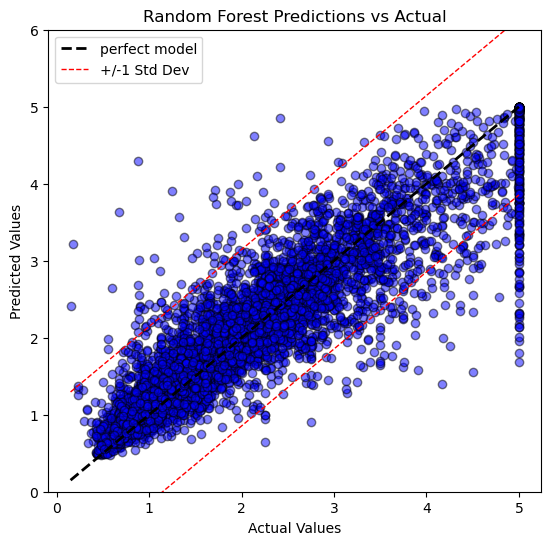

In [42]:
plt.figure(figsize=(14, 6))

# Random Forest plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_rf, alpha=0.5, color="blue",ec='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2,label="perfect model")
plt.plot([y_test.min(), y_test.max()], [y_test.min() + std_y, y_test.max() + std_y], 'r--', lw=1, label="+/-1 Std Dev")
plt.plot([y_test.min(), y_test.max()], [y_test.min() - std_y, y_test.max() - std_y], 'r--', lw=1, )
plt.ylim(0,6)
plt.title("Random Forest Predictions vs Actual")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.show()